## Author profiling

Author profiling is a supervised clasification technique to identify demographic characteristics of an objective group. In this task, given the text of a Twitter feed, we'll determine the authors nationality and gender.


## 1. The sets are divided only in traning and val, we add a testing set.

In [1]:
import torch
print(torch.__file__)
print(torch.version.cuda)
print(torch.cuda.is_available())

c:\Users\disom\OneDrive\CIMAT\python_code\NLP\.venv\Lib\site-packages\torch\__init__.py
12.6
True


In [2]:
import os
os.getcwd()

'c:\\Users\\disom\\OneDrive\\CIMAT\\python_code\\NLP\\Examen 2'

In [ ]:
import pickle
import pandas as pd
from sklearn.model_selection import train_test_split

def dic_to_pd(dic):    
    rows = []
    with open(dic + '.pkl', 'rb') as f:
        dic_data = pickle.load(f)
        for author_id, info in dic_data.items():
            row = {
                'author': author_id,
                'tweets': [' '.join(tweet)for tweet in info['tweets']],
                'gender': info['gender'],
                'gender_label': 1 if info['gender'] == 'female' else 0,
                'nationality': info['nationality'],
                'nationality_label': info['target']
            }
            rows.append(row)
        
        data = pd.DataFrame(rows)
    return data

df_all = pd.concat([dic_to_pd("train_dict"), dic_to_pd("val_dict")], ignore_index=True)
print(f"Total samples: {len(df_all)}")

# separate in three sets:
# First split: train vs temp (val+test)
df_train_final, df_temp = train_test_split(
    df_all, test_size=0.4, random_state=42, stratify=df_all['nationality_label'])

# Second split: val vs test
df_val_final, df_test_final = train_test_split(
    df_temp, test_size=0.5, random_state=42, stratify=df_temp['nationality_label'])

print(f"Train: {len(df_train_final)}, Val: {len(df_val_final)}, Test: {len(df_test_final)}")

df_train_final.to_pickle('train.pkl')
df_val_final.to_pickle('val.pkl')
df_test_final.to_pickle('test.pkl')


Total samples: 4200
Train: 2520, Val: 840, Test: 840


In [135]:
df_train_final.head()

,author,tweets,gender,gender_label,nationality,nationality_label
4165,f533521167cdb5e82a1f3872e6452be4,[que rabia las viejas que están o estuvieron e...,female,1,colombia,2
2168,aca0c70204a1392fa1b5cd1531bb43f4,[tengo que aprender a confiar en mí a valorarm...,male,0,spain,5
4090,df60850634270020f0acd246bcfd54a2,[sebastián piñera eligió a rodrigo hinzpeter c...,male,0,chile,1
949,56c71b18b0cf698df5c2abbf2753cb6e,[jimmy en #lavajato #odebrecht etc habían pode...,female,1,peru,4
1567,7f8aa891afa901feb0abfe57490e0eca,[nooo tocó un payaso en mi grupo ha aguantarlo...,female,1,peru,4


In [122]:
print("Train nationality distribution:")
print(df_train_final['nationality_label'].value_counts(normalize=True))
print("\nValidation nationality distribution:")
print(df_val_final['nationality_label'].value_counts(normalize=True))
print("\nTest nationality distribution:")
print(df_test_final['nationality_label'].value_counts(normalize=True))

print("Train gender distribution:")
print(df_train_final['gender_label'].value_counts(normalize=True))
print("\nValidation gender distribution:")
print(df_val_final['gender_label'].value_counts(normalize=True))
print("\nTest gender distribution:")
print(df_test_final['gender_label'].value_counts(normalize=True))

Train nationality distribution:
nationality_label
2    0.142857
5    0.142857
1    0.142857
4    0.142857
3    0.142857
0    0.142857
6    0.142857
Name: proportion, dtype: float64

Validation nationality distribution:
nationality_label
5    0.142857
6    0.142857
3    0.142857
2    0.142857
1    0.142857
0    0.142857
4    0.142857
Name: proportion, dtype: float64

Test nationality distribution:
nationality_label
4    0.142857
6    0.142857
5    0.142857
1    0.142857
2    0.142857
3    0.142857
0    0.142857
Name: proportion, dtype: float64
Train gender distribution:
gender_label
0    0.505159
1    0.494841
Name: proportion, dtype: float64

Validation gender distribution:
gender_label
1    0.505952
0    0.494048
Name: proportion, dtype: float64

Test gender distribution:
gender_label
1    0.509524
0    0.490476
Name: proportion, dtype: float64


## 2. Model building

Data was already inspected in the HAN module. Now well deal exclusively with model building. The selected implementation will be a RoBERTuito, a bidirectional encoder trained for classification on spanish tweets.

In [1]:
import numpy as np
from tqdm.auto import tqdm
import numpy as np
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F


c:\Users\disom\OneDrive\CIMAT\python_code\NLP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch
from torch.utils.data import Dataset
from torch.nn.utils.rnn import pad_sequence
import pandas as pd
from transformers import AutoTokenizer
from pysentimiento.preprocessing import preprocess_tweet

class TweetDataset(Dataset):
    def __init__(self, split):
        super(Dataset, self).__init__()
        self.tokenizer = AutoTokenizer.from_pretrained('pysentimiento/robertuito-base-uncased')
        #Load data
        self.load_data(split)

    def load_data(self, split):
        '''Loads author-level data from .csv'''
        self.data = pd.read_pickle(split+".pkl")
        
    def __len__(self):
        return len(self.data)

    def preprocessed_text(self, index):
        '''Tokenize text and get words'''
        tweets=[]
        tweets_id=[]
                
        for tweet in self.data.iloc[index]['tweets']:
            preprocessed=preprocess_tweet(tweet)
            encoded = self.tokenizer.encode_plus(
                                    preprocessed,
                                    add_special_tokens=True,
                                    truncation=True,
                                    max_length=130, # based in roberta limit embedding
                                    return_tensors=None,  # return lists
                                    return_token_type_ids=False,
                                    return_attention_mask=True,
                                )
                
            tweets_id.append(torch.tensor(encoded["input_ids"]))
            tweets.append(self.tokenizer.convert_ids_to_tokens(encoded['input_ids']))
            
        return tweets_id, tweets

    def __getitem__(self, index):
        '''Returns token IDs, label, and raw tokens for a user.'''
        nationality_label = self.data.iloc[index]['nationality_label']
        gender_label = self.data.iloc[index]['gender_label']        
        tweets_id, tweets = self.preprocessed_text(index)
        
        return tweets_id, tweets, nationality_label, gender_label
    
    def get_weights(self,label_col):
        '''Returns inverse class frequency weights for each class.
        Call for each specific category'''

        counts = self.data[label_col].value_counts().sort_index()
        max_count = counts.max()
        weights = [max_count / c for c in counts]
        return torch.tensor(weights, dtype=torch.float32)
        
    def collate_fn(self, batch):
        """
        Return all items from the dataset
        """
        tweets_ids = []
        attention_masks = []
        tweets = []
        lengths = []
        nationality_labels, gender_labels = [], []

        for tweet_i, tweet_t, nat_label, gen_label in batch:
            padded_ids = pad_sequence(tweet_i, batch_first=True, padding_value=0)
            attention_m = (padded_ids != 0).long()  # mask where token != padding
            tweets_ids.append(padded_ids)
            attention_masks.append(attention_m)
            tweets.append(tweet_t)
            lengths.append([len(t) for t in tweet_i])
            nationality_labels.append(nat_label)
            gender_labels.append(gen_label)

        return tweets_ids, attention_masks, tweets, torch.tensor(nationality_labels), torch.tensor(gender_labels), lengths
    

In [3]:
train_dataset = TweetDataset('train')
train_dataloader = DataLoader(train_dataset, batch_size=1, collate_fn = train_dataset.collate_fn, shuffle=True)

padded_tweet_ids, attn_m, tweets, nationality_label, gender_label, lengths = next(iter(train_dataloader))

print(padded_tweet_ids[0])
print(attn_m[0][0])
print(tweets[0][0])
print(nationality_label)
print(gender_label)
print(lengths[0][0])


tensor([[   0,  431,  445,  ...,    0,    0,    0],
        [   0,  431,  583,  ...,    0,    0,    0],
        [   0,  443, 1292,  ...,    0,    0,    0],
        ...,
        [   0,  439, 6917,  ...,    0,    0,    0],
        [   0, 2519,  413,  ...,    0,    0,    0],
        [   0, 2519,  413,  ...,    0,    0,    0]])
tensor([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0])
['<s>', '▁@usuario', '▁y', '▁hay', '▁tratamiento', '▁para', '▁eso', '▁', '▁emoji', '▁cara', '▁pensativa', '▁emoji', '▁', '▁', '▁emoji', '▁cara', '▁pensativa', '▁emoji', '</s>']
tensor([2])
tensor([1])
19


In [4]:
from transformers import AutoModel

#model = AutoModel.from_pretrained("pysentimiento/robertuito-base-uncased")

#model


In [5]:
import torch
import torch.nn as nn
from transformers import AutoModel
  
    
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size, hidden_size)
        self.context_vector = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, inputs):
        # inputs: (batch_size, seq_len, hidden_size)
        attn_hidden = torch.tanh(self.attn(inputs))  # (batch_size, seq_len, hidden_size)
        scores = self.context_vector(attn_hidden).squeeze(-1)  # (batch_size, seq_len)
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)  # (batch_size, seq_len, 1)
        context = (inputs * weights).sum(dim=1)  # (batch_size, hidden_size)
        return context, weights

    
class HANEncoder(nn.Module):
    """
    Bidirectional GRU + projection + attention.
    Input: (batch_size, num_tweets, input_dim)
    Output: (batch_size, 2 * hidden_dim)
    """
    def __init__(self, input_dim, projection_dim, hidden_dim, bidirectional=True):
        super().__init__()
        self.projection = nn.Linear(input_dim, projection_dim, bias=False)
        self.gru = nn.GRU(projection_dim, hidden_dim, batch_first=True, bidirectional=bidirectional)
        self.directions = 2 if bidirectional else 1
        self.attention = Attention(hidden_dim * self.directions)

    def forward(self, tweet_embeddings):  # (batch_size, num_tweets, input_dim)
        projected = self.projection(tweet_embeddings)  # (batch_size, num_tweets, projection_dim)
        gru_out, _ = self.gru(projected)  # (batch_size, num_tweets, hidden_dim * 2)
        context, attn_weights = self.attention(gru_out)  # vectorizada
        return context, attn_weights


class HierarchicalUserClassifier(nn.Module):
    def __init__(self, projection_dim, hidden_dim, num_nationalities, num_genders, bidirectional=True):
        super().__init__()

        # 1. RoBERTuito 
        self.robertuito = AutoModel.from_pretrained('pysentimiento/robertuito-base-uncased')
        roberta_output_dim = self.robertuito.config.hidden_size  # usualmente 768

        # 2. HANEncoder with atenttion
        self.encoder = HANEncoder(
            input_dim=roberta_output_dim,
            projection_dim=projection_dim,
            hidden_dim=hidden_dim,
            bidirectional=bidirectional
        )
        self.directions = 2 if bidirectional else 1
        encoded_dim = hidden_dim * self.directions # bidirectionality

        # 3. Clasification
        self.nationality_classifier = nn.Linear(encoded_dim, num_nationalities)
        self.gender_classifier = nn.Linear(encoded_dim, num_genders)

    def forward(self, tweet_batch,attention_masks):
        """
        tweet_batch: list of [num_tweets, seq_len] tensors, len = batch_size
        attention_masks: list of [num_tweets, seq_len] tensors, aligned with tweet_batch
        """
        device = next(self.parameters()).device

        tweet_embeddings = []
        #checking if all tweets have the same shape
        max_tweets = max([input_ids.shape[0] for input_ids in tweet_batch])
        
        for input_ids, attention_mask in zip(tweet_batch, attention_masks):
            input_ids = input_ids.to(device)
            attention_mask = attention_mask.to(device)

            with torch.no_grad():
                outputs = self.robertuito(input_ids=input_ids, attention_mask=attention_mask)
                cls_embeddings = outputs.last_hidden_state[:, 0, :]  # (num_tweets, 768)

                if cls_embeddings.size(0) < max_tweets:
                    #padd the missing embedings to reach the 100 tweets
                    padding = torch.zeros((max_tweets - cls_embeddings.size(0), cls_embeddings.size(1)), device=device)
                    cls_embeddings = torch.cat([cls_embeddings, padding], dim=0)
                    
            tweet_embeddings.append(cls_embeddings)
        
        # Stack embeddings
        tweet_embeddings = torch.stack(tweet_embeddings, dim=0)  # (batch_size, num_tweets, 768)

        # HAN Encoder with attention
        context, attn_weights = self.encoder(tweet_embeddings)  # (batch_size, hidden_dim*2)

        # Clasification
        nationality_logits = self.nationality_classifier(context)
        gender_logits = self.gender_classifier(context)

        return nationality_logits, gender_logits, attn_weights


## Model run

In [33]:
from sklearn.metrics import f1_score, accuracy_score
from tqdm import tqdm
import torch.nn.functional as F

def eval_model(model, dataloader, nat_criterion, gen_criterion, device='cuda', average='macro'):
    '''Evaluate the HAN model and return loss, F1, accuracy, and attention scores.

    Args:
        model: PyTorch model with attention mechanism.
        dataloader: DataLoader providing evaluation batches.
        criterion: Loss function (e.g., CrossEntropyLoss).
        device: 'cpu' or 'cuda' depending on setup.
        average: Type of averaging for F1-score ('macro', 'weighted', etc.)

    Returns:
        Dictionary with loss, F1, accuracy, and attention-related information.
    '''
    model.eval()
    model.to(device)

    losses = []
    nat_preds, gen_preds = [], []
    nat_target, gen_target = [], []
    tweet_list = []
    doc_attn = []

    with torch.no_grad():
        for data in tqdm(dataloader, desc='Evaluating'):
            padded_tweet_ids, attn_m, tweets, nationality_label, gender_label, lengths =data

            # Move inputs to the appropriate device
            padded_tweet_ids = [t.to(device) for t in padded_tweet_ids]
            attn_m = [a.to(device) for a in attn_m] 
            #Save labels
            nationality_label = nationality_label.to(device)
            gender_label = gender_label.to(device)
            # Save targets
            nat_target.extend(nationality_label.cpu().tolist())
            gen_target.extend(gender_label.cpu().tolist())
            
            # Forward pass through the model
            nationality_logits, gender_logits, attn_weights = model(padded_tweet_ids, attn_m) # Output logits output tensor, wscore list, dscoress tensor
            loss_nat = nat_criterion(nationality_logits, nationality_label)
            loss_gen = gen_criterion(gender_logits, gender_label)
            loss = loss_nat+loss_gen  # multitask loss: nationality + gender
            losses.append(loss.item()) #get torch value

            #Save predictions
            nat_preds.extend(nationality_logits.argmax(1).cpu().tolist())
            gen_preds.extend(gender_logits.argmax(1).cpu().tolist())

            tweet_list += tweets
            doc_attn += attn_weights

    model.train()

    # Calculate and save global metrics
    return {
        'loss': np.mean(losses),
        'f1_gender': f1_score(gen_target, gen_preds, average=average),
        'accuracy_gender': accuracy_score(gen_target, gen_preds),
        'f1_nationality': f1_score(nat_target, nat_preds, average=average),
        'accuracy_nationality': accuracy_score(nat_target, nat_preds),
        'tweet_list': tweet_list,
        'gender_prediction': gen_preds,
        'gender_label': gen_target,
        'nationality_prediction': nat_preds,
        'nationality_label': nat_target,
        'attn_weights': doc_attn
    }


In [39]:
import copy
from tqdm import tqdm
import torch

def train_model(
    model, train_dataloader, val_dataloader,
    nat_criterion, gen_criterion, optimizer,
    epochs=10, device='cuda', checkpoint_path='han_checkpoint.pth'):

    best_score = 0
    best_state_dict = None

    train_stats = []
    val_stats = []

    model.to(device)
    nat_criterion.weight = nat_criterion.weight.to(device)
    gen_criterion.weight = gen_criterion.weight.to(device)


    for epoch in range(epochs):
        model.train()
        epoch_loss = 0

        print(f"\nEpoch {epoch+1}/{epochs}")

        for batch in tqdm(train_dataloader, desc="Training"):
            optimizer.zero_grad()

            padded_tweet_ids, attn_m, tweets, nationality_label, gender_label, lengths = batch
            
            padded_tweet_ids = [t.to(device) for t in padded_tweet_ids]
            attn_m = [a.to(device) for a in attn_m] 
            
            nationality_label = nationality_label.to(device)
            gender_label = gender_label.to(device)

            # Forward pass
            nationality_logits, gender_logits, attn_weights = model(padded_tweet_ids,attn_m)
            #print("Logits:", nationality_logits.device)
            #print("Labels:", nationality_label.device)
            #print("Weight:", nat_criterion.weight.device)
            #print("Logits:", gender_logits.device)
            #print("Labels:", gender_label.device)
            #print("Weight:", gen_criterion.weight.device)
            
            loss_nat = nat_criterion(nationality_logits.to(device), nationality_label)
            loss_gen = gen_criterion(gender_logits.to(device), gender_label)
            loss = loss_nat + loss_gen

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  #stabilize gradients
            optimizer.step()

            epoch_loss += loss.item()

        #Evaluation
        train_eval = eval_model(model, train_dataloader, nat_criterion, gen_criterion, device)
        val_eval = eval_model(model, val_dataloader, nat_criterion, gen_criterion, device)

        train_stats.append(train_eval)
        val_stats.append(val_eval)

        #Print metrics
        print(f"Train Loss: {train_eval['loss']:.4f} | F1_Gender: {train_eval['f1_gender']:.4f} | F1_Nat: {train_eval['f1_nationality']:.4f}")
        print(f"Val   Loss: {val_eval['loss']:.4f} | F1_Gender: {val_eval['f1_gender']:.4f} | F1_Nat: {val_eval['f1_nationality']:.4f}")
        print(f"Accuracy_Gender     (Train/Val): {train_eval['accuracy_gender']:.4f} / {val_eval['accuracy_gender']:.4f}")
        print(f"Accuracy_Nationality(Train/Val): {train_eval['accuracy_nationality']:.4f} / {val_eval['accuracy_nationality']:.4f}")

        #Save best model based on composite score
        current_score = val_eval["f1_gender"] + val_eval["f1_nationality"]
        if current_score > best_score:
            best_score = current_score
            best_state_dict = copy.deepcopy(model.state_dict())
            torch.save({
                'epoch': epoch,
                'model_state_dict': best_state_dict,
                'optimizer_state_dict': optimizer.state_dict(),
                'train_log': train_stats,
                'val_log': val_stats
            }, checkpoint_path)
            print("Best model saved.\n")

    # Reload best weights
    model.load_state_dict(best_state_dict)
    return model, best_state_dict, train_stats, val_stats


In [40]:
lr = 0.0001
epochs = 20
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
weight_decay=0.0001
beta1=0.0
beta2=0.999
batch_size=30

In [41]:
train_dataset = TweetDataset('train')
val_dataset = TweetDataset('val')
test_dataset = TweetDataset('test')
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, collate_fn = train_dataset.collate_fn, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, collate_fn = val_dataset.collate_fn, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, collate_fn = test_dataset.collate_fn, shuffle=False)

In [42]:
#Roberta dim=768 projection dim=128 hidden dim 128
model = HierarchicalUserClassifier(projection_dim=128, hidden_dim=128, num_nationalities=7, num_genders=2, bidirectional=True).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr,weight_decay=weight_decay, betas = (beta1, beta2))
nat_criterion = nn.CrossEntropyLoss(weight=train_dataset.get_weights("nationality_label").to(device))
gen_criterion = nn.CrossEntropyLoss(weight=train_dataset.get_weights("gender_label").to(device))


In [43]:
model, best_state_dict, train_stats, val_stats = train_model(
                                model, train_dataloader, val_dataloader,
                                nat_criterion, gen_criterion, optimizer,
                                epochs=6, device=device, checkpoint_path='han_checkpoint.pth')
#model.load_state_dict(best_weights)


Epoch 1/6


Evaluating: 100%|██████████| 28/28 [06:57<00:00, 14.92s/it]


Train Loss: 2.4744 | F1_Gender: 0.5415 | F1_Nat: 0.2986
Val   Loss: 2.5108 | F1_Gender: 0.5386 | F1_Nat: 0.2971
Accuracy_Gender     (Train/Val): 0.5758 / 0.5798
Accuracy_Nationality(Train/Val): 0.3242 / 0.3119
Best model saved.


Epoch 2/6


Evaluating: 100%|██████████| 28/28 [06:53<00:00, 14.78s/it]


Train Loss: 1.9986 | F1_Gender: 0.6244 | F1_Nat: 0.5043
Val   Loss: 2.0579 | F1_Gender: 0.6241 | F1_Nat: 0.4723
Accuracy_Gender     (Train/Val): 0.6349 / 0.6393
Accuracy_Nationality(Train/Val): 0.5480 / 0.5119
Best model saved.


Epoch 3/6


...

Train Loss: 1.3764 | F1_Gender: 0.6989 | F1_Nat: 0.7629
Val   Loss: 1.4770 | F1_Gender: 0.6842 | F1_Nat: 0.7258
Accuracy_Gender     (Train/Val): 0.6992 / 0.6857
Accuracy_Nationality(Train/Val): 0.7754 / 0.7381
Best model saved.


Epoch 5/6


Evaluating: 100%|██████████| 28/28 [06:51<00:00, 14.69s/it]


Train Loss: 1.1446 | F1_Gender: 0.7068 | F1_Nat: 0.8409
Val   Loss: 1.2792 | F1_Gender: 0.6817 | F1_Nat: 0.8052
Accuracy_Gender     (Train/Val): 0.7079 / 0.6845
Accuracy_Nationality(Train/Val): 0.8448 / 0.8095
Best model saved.


Epoch 6/6


Evaluating: 100%|██████████| 28/28 [06:43<00:00, 14.42s/it]

Train Loss: 1.0989 | F1_Gender: 0.6361 | F1_Nat: 0.8664
Val   Loss: 1.2315 | F1_Gender: 0.6384 | F1_Nat: 0.8354
Accuracy_Gender     (Train/Val): 0.6556 / 0.6619
Accuracy_Nationality(Train/Val): 0.8679 / 0.8357


In [46]:
model.train()
model.to(device)
model, best_state_dict, new_train_log, new_val_log = train_model(
    model,
    train_dataloader,
    val_dataloader,
    nat_criterion,
    gen_criterion,
    optimizer,
    epochs=3,
    device=device,
    checkpoint_path='han_checkpoint.pth'
)


Epoch 1/3


Evaluating: 100%|██████████| 28/28 [07:03<00:00, 15.14s/it]


Train Loss: 1.0599 | F1_Gender: 0.7027 | F1_Nat: 0.8657
Val   Loss: 1.2084 | F1_Gender: 0.6864 | F1_Nat: 0.8247
Accuracy_Gender     (Train/Val): 0.7040 / 0.6893
Accuracy_Nationality(Train/Val): 0.8671 / 0.8250
Best model saved.


Epoch 2/3


Evaluating: 100%|██████████| 28/28 [07:06<00:00, 15.24s/it]


Train Loss: 1.0177 | F1_Gender: 0.7034 | F1_Nat: 0.8790
Val   Loss: 1.1668 | F1_Gender: 0.6801 | F1_Nat: 0.8462
Accuracy_Gender     (Train/Val): 0.7063 / 0.6821
Accuracy_Nationality(Train/Val): 0.8786 / 0.8452
Best model saved.


Epoch 3/3


Evaluating: 100%|██████████| 28/28 [07:02<00:00, 15.09s/it]

Train Loss: 1.0030 | F1_Gender: 0.6848 | F1_Nat: 0.8741
Val   Loss: 1.1232 | F1_Gender: 0.6730 | F1_Nat: 0.8333
Accuracy_Gender     (Train/Val): 0.6944 / 0.6869
Accuracy_Nationality(Train/Val): 0.8758 / 0.8333


In [48]:
#model.load_state_dict(best_state_dict)
train_dic = eval_model(model, train_dataloader, nat_criterion, gen_criterion)
val_dic  = eval_model(model, val_dataloader, nat_criterion, gen_criterion)
test_dic =eval_model(model, test_dataloader, nat_criterion, gen_criterion)
print(f"Train Loss: {train_dic['loss']:.4f} | F1_Gender: {train_dic['f1_gender']:.4f} | F1_Nat: {train_dic['f1_nationality']:.4f}")
print(f"Val   Loss: {val_dic['loss']:.4f} | F1_Gender: {val_dic['f1_gender']:.4f} | F1_Nat: {val_dic['f1_nationality']:.4f}")
print(f"Test   Loss: {val_dic['loss']:.4f} | F1_Gender: {val_dic['f1_gender']:.4f} | F1_Nat: {val_dic['f1_nationality']:.4f}")

Evaluating: 100%|██████████| 28/28 [17:53<00:00, 38.36s/it]


Train Loss: 1.0177 | F1_Gender: 0.7034 | F1_Nat: 0.8790
Val   Loss: 1.1668 | F1_Gender: 0.6801 | F1_Nat: 0.8462
Test   Loss: 1.1668 | F1_Gender: 0.6801 | F1_Nat: 0.8462


In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusion_matrices(results_dict, split_name, labels_gender=None, labels_nationality=None):
    # Matriz de confusión para género
    cm_gender = confusion_matrix(results_dict['gender_label'], results_dict['gender_prediction'])
    disp_gender = ConfusionMatrixDisplay(confusion_matrix=cm_gender, display_labels=labels_gender)
    disp_gender.plot(cmap=plt.cm.Blues)
    plt.title(f'{split_name} - Confusion Matrix: Gender')
    plt.show()

    # Matriz de confusión para nacionalidad
    cm_nat = confusion_matrix(results_dict['nationality_label'], results_dict['nationality_prediction'])
    disp_nat = ConfusionMatrixDisplay(confusion_matrix=cm_nat, display_labels=labels_nationality)
    disp_nat.plot(cmap=plt.cm.Blues)
    plt.title(f'{split_name} - Confusion Matrix: Nationality')
    plt.show()

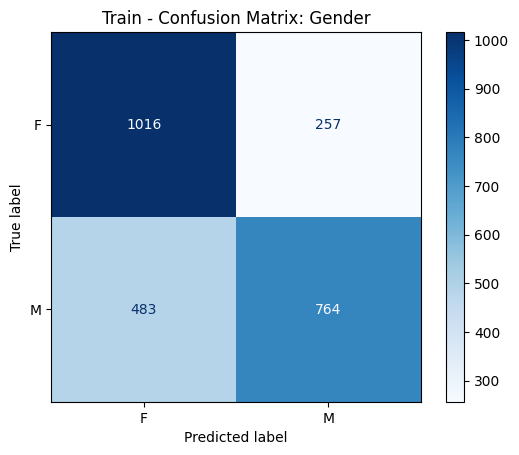

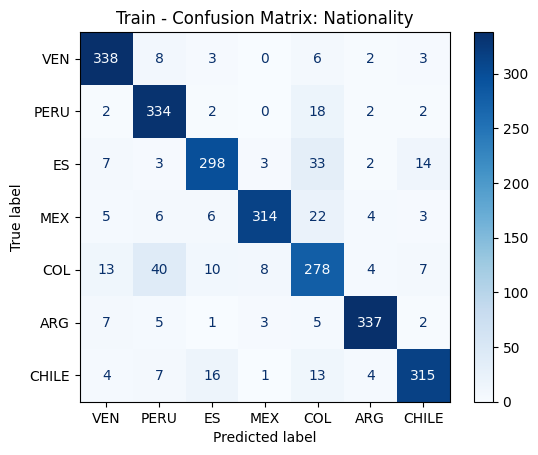

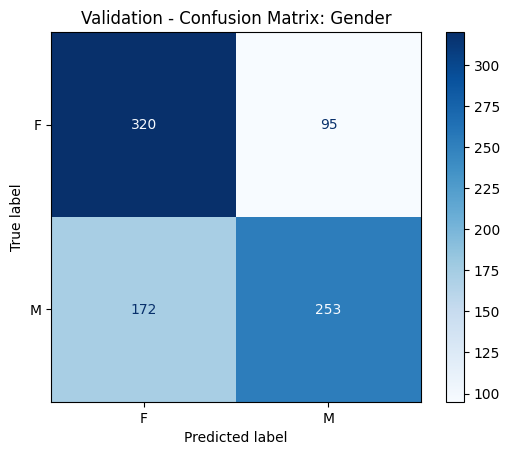

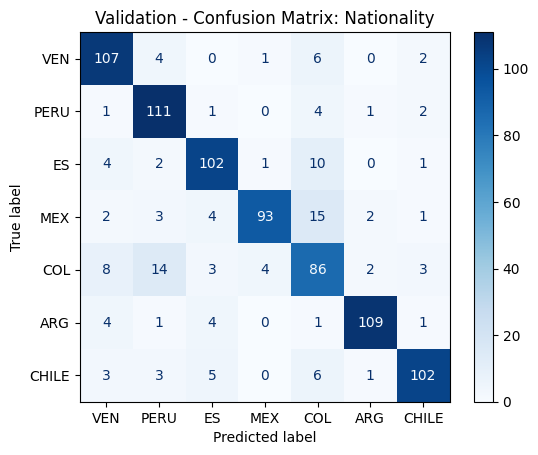

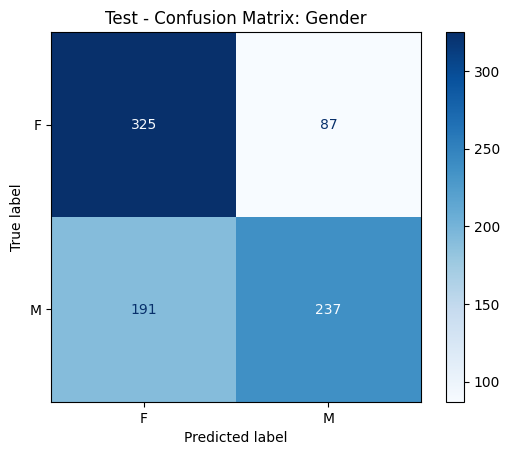

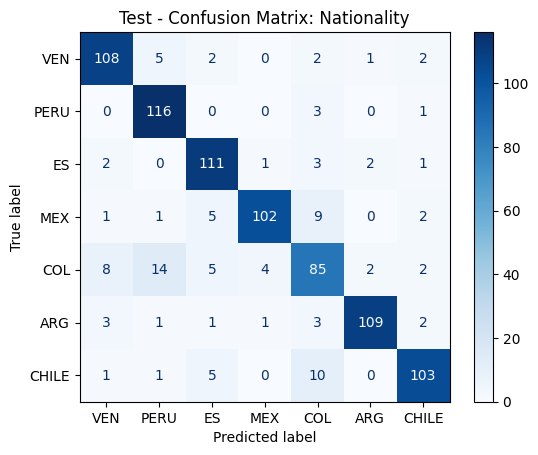

In [55]:
plot_confusion_matrices(train_dic, "Train", labels_gender=["F", "M"], labels_nationality=["VEN", "PERU", "ES","MEX","COL", "ARG", "CHILE"])
plot_confusion_matrices(val_dic, "Validation", labels_gender=["F", "M"], labels_nationality=["VEN", "PERU", "ES","MEX","COL", "ARG", "CHILE"])
plot_confusion_matrices(test_dic, "Test", labels_gender=["F", "M"], labels_nationality=["VEN", "PERU", "ES","MEX","COL", "ARG", "CHILE"])

